In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
arquivo = '/content/matriz_risco_fundos.csv'
df = pd.read_csv(arquivo)

colunas_originais = df.columns[-3:].tolist()
print(f"Colunas detectadas para o cálculo: {colunas_originais}")

dados = df[colunas_originais]

scaler = StandardScaler()
dados_esc = scaler.fit_transform(dados)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(dados_esc)
print(f"Silhueta k-means : {silhouette_score(dados_esc, kmeans.fit_predict(dados_esc)):.3f}")
dbscan = DBSCAN(eps=0.5, min_samples=3)
df['cluster_dbscan'] = dbscan.fit_predict(dados_esc)
print(f"Silhueta dbscan : {silhouette_score(dados_esc, dbscan.fit_predict(dados_esc)):.3f}")
df.to_csv('matriz_final.csv', index=False)



Colunas detectadas para o cálculo: ['DIAS_OPERADOS', 'RETORNO_MEDIO_DIARIO', 'VOLATILIDADE_RISCO']
Silhueta k-means : 0.994
Silhueta dbscan : 0.954


           CNPJ_FUNDO  DIAS_OPERADOS  RETORNO_MEDIO_DIARIO  \
0  17.940.400/0001-80            102              0.000216   
1  34.231.938/0001-34            102              0.000415   
2  30.419.203/0001-88            102              0.000521   
3  35.602.471/0001-54            102              0.000214   
4  40.944.483/0001-05            102              0.000946   

   VOLATILIDADE_RISCO  cluster_kmeans  status_dbscan  
0            0.001861               0              0  
1            0.002841               0              0  
2            0.000006               0              0  
3            0.009897               0              0  
4            0.005417               0              0  
[0 2 1]
Grupo 0: 3904 membros
Grupo 2: 15 membros
Grupo 1: 1 membros
3


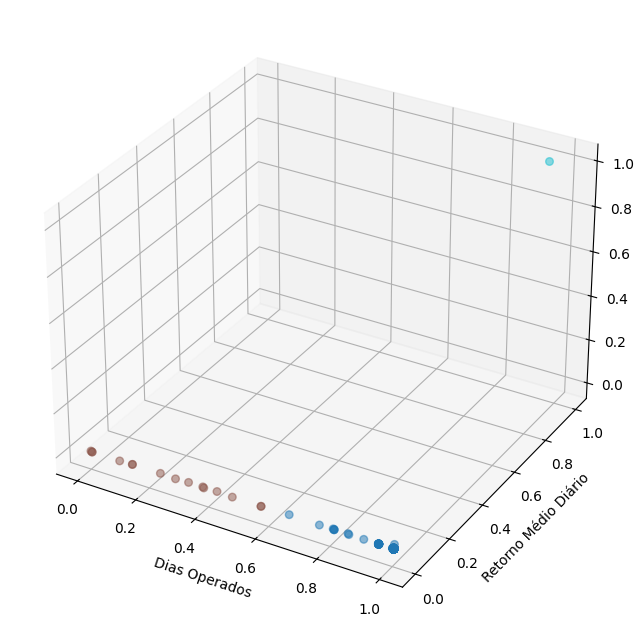

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
#exibe informações basicas
df = pd.read_csv('/content/matriz_final.csv')
print(df.head())
grupos = df['cluster_kmeans'].unique()
print(grupos)
#normalizar
cols_normalizar = ['DIAS_OPERADOS', 'RETORNO_MEDIO_DIARIO', 'VOLATILIDADE_RISCO']
for col in cols_normalizar:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col + '_norm'] = (df[col] - min_val) / (max_val - min_val)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
cores = plt.cm.tab10(np.linspace(0, 1, len(grupos)))

# Plotar cada grupo com uma cor diferente
for i, grupo in enumerate(grupos):
    df_grupo = df[df['cluster_kmeans'] == grupo]
    print(f"Grupo {grupo}: {len(df_grupo)} membros")
    ax.scatter(
        df_grupo['DIAS_OPERADOS_norm'],
        df_grupo['RETORNO_MEDIO_DIARIO_norm'],
        df_grupo['VOLATILIDADE_RISCO_norm'],
        color=cores[i],
        label=f'Grupo {grupo}',
        alpha=0.5,
        s=30
    )
print(len(grupos))
ax.set_xlabel('Dias Operados')
ax.set_ylabel('Retorno Médio Diário')
plt.show()

           CNPJ_FUNDO  DIAS_OPERADOS  RETORNO_MEDIO_DIARIO  \
0  17.940.400/0001-80            102              0.000216   
1  34.231.938/0001-34            102              0.000415   
2  30.419.203/0001-88            102              0.000521   
3  35.602.471/0001-54            102              0.000214   
4  40.944.483/0001-05            102              0.000946   

   VOLATILIDADE_RISCO  cluster_kmeans  cluster_dbscan  
0            0.001861               0               0  
1            0.002841               0               0  
2            0.000006               0               0  
3            0.009897               0               0  
4            0.005417               0               0  
[ 0  1 -1  2]
Grupo 0: 3872 membros
Grupo 1: 22 membros
Grupo -1: 23 membros
Grupo 2: 3 membros
4


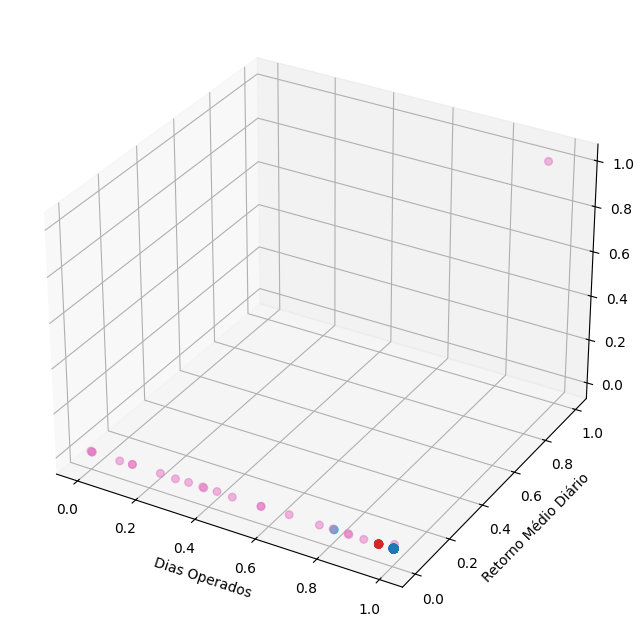

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
#exibe informações basicas
df = pd.read_csv('/content/matriz_final.csv')
print(df.head())
grupos = df['cluster_dbscan'].unique()
print(grupos)
#normalizar
cols_normalizar = ['DIAS_OPERADOS', 'RETORNO_MEDIO_DIARIO', 'VOLATILIDADE_RISCO']
for col in cols_normalizar:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col + '_norm'] = (df[col] - min_val) / (max_val - min_val)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
cores = plt.cm.tab10(np.linspace(0, 1, len(grupos)))

# Plotar cada grupo com uma cor diferente
for i, grupo in enumerate(grupos):
    df_grupo = df[df['cluster_dbscan'] == grupo]
    print(f"Grupo {grupo}: {len(df_grupo)} membros")
    ax.scatter(
        df_grupo['DIAS_OPERADOS_norm'],
        df_grupo['RETORNO_MEDIO_DIARIO_norm'],
        df_grupo['VOLATILIDADE_RISCO_norm'],
        color=cores[i],
        label=f'Grupo {grupo}',
        alpha=0.5,
        s=30
    )
print(len(grupos))
ax.set_xlabel('Dias Operados')
ax.set_ylabel('Retorno Médio Diário')
plt.show()